# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:Praveen Baby
### Date:

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [41]:
# TODO: shape, dtypes, missing value summary
df.shape
df.dtypes
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [43]:
# TODO: check for values that are technically present but don't make real-world sense
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [44]:
# TODO: duplicate check
df.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
...,...
48890,False
48891,False
48892,False
48893,False


**Written notes — what did you find, and what looks suspicious?**

The dataset contains 48,895 rows and 16 columns with no duplicate records. The last_review column is in object datatype and may need to be converted to datetime. The price column has a minimum value of 0, which looks suspicious, while minimum_nights has a maximum of 1,250, which may be an outlier. Since id, name, host_id, and host_name are not required for our analysis, we can remove these columns, so the missing values in name and host_name do not need to be handled.


---
## Part 2 — Missing Value Diagnosis & Treatment

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [46]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [47]:
# TODO: investigate missingness pattern(s) across columns
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

Number of missing value in both columns are same its because there was no reviews and hence no last review date. So i.m going to drop the column last_review because more than 20% are missing. Missing value in reviews_per_month are gonna be replaced by 0

In [48]:
# TODO: apply your chosen treatment(s)
df = df.drop(['id', 'name', 'host_id', 'host_name'],axis=1)

In [49]:
df = df.drop(['last_review'],axis=1)


In [50]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [51]:
df


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**
 could keep the columns and give an imaginary date but that could influence model too much as its over 20% so I'd rather risk with dropping the column. But this method can cause lose in current popularity and booking recency in the data.

---
## Part 3 — Outlier Detection & Treatment


In [52]:
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

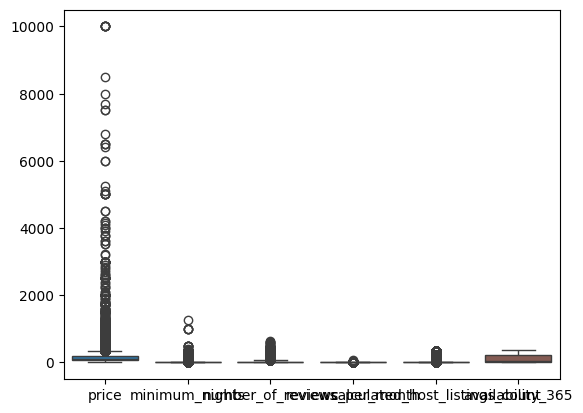

In [53]:
# TODO: detect outliers in at least two numeric columns
sns.boxplot(df[[
        'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count','availability_365']])
plt.show()

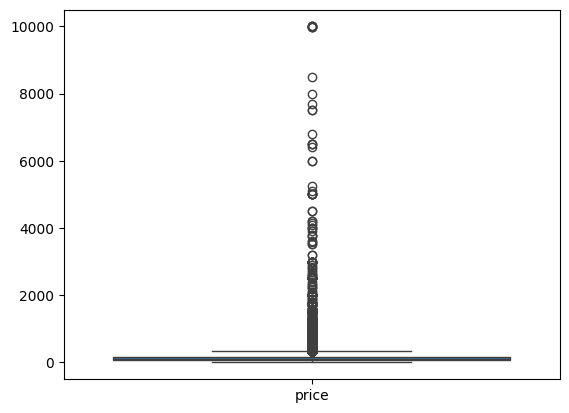

In [54]:
sns.boxplot(df[[
        'price' ]])
plt.show()

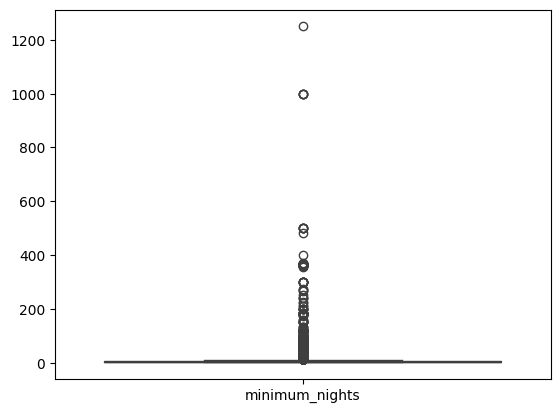

In [55]:
sns.boxplot(df[[
        'minimum_nights']])
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

_in case of price 0 is definitely an error and 10000 s a huge value so i'm going to cap each values not to the lower limit and upper limit but minimum 30 and maximum 2000 dollars.As for minimum nights i'm going to cap the outliers to lower limit and upper limit._

In [56]:
# TODO: apply treatment consistent with your  judgment above
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

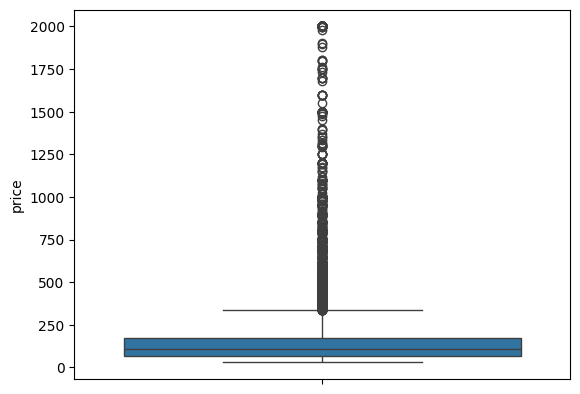

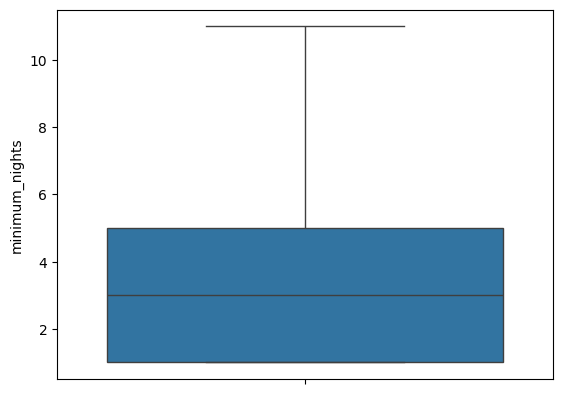

In [57]:
sns.boxplot(df['price'])
plt.show()
sns.boxplot(df['minimum_nights'])
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [58]:
# TODO: encode categorical columns appropriately
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


In [59]:
# TODO: engineer at least two new features
df['neighbourhood'].unique()


array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [60]:
frequency = df['neighbourhood'].value_counts()

df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [61]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [62]:

from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(
    categories=[['Shared room', 'Private room', 'Entire home/apt']]
)
df['room_type']=encoder.fit_transform(df[['room_type']])

In [63]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [64]:
df=pd.get_dummies(df,prefix='group',dtype='int',drop_first=True)

In [65]:
df.head()
df=df.drop(['latitude','longitude'],axis =1)

**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

_
_First 4 columns are dropped they we id,name,host_id,host_name. They don't need to be present for prediction. Also latitude and longitude doesn't provide any pupose when it comes to ml modelling in this case. other  object column were handled neighbourhood is handled by frequency encoder, room_type has ordinal data so ordinal encoding is done and for neighbourhood_group OneHotEncoding is done_._

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [66]:
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [67]:
# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()
# Missing value handling and removing Unnecessary columns
df=df.drop(['last_review','id','name','host_id','host_name','latitude','longitude'],axis=1)
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [68]:
# Outlier Management
# PRICE
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

#Encoding:
# neighbourhood - frequency encoding,
frequency = df['neighbourhood'].value_counts()
df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])



0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [69]:
# TODO: train/test split (before fitting anything)
# Seperate X and Y
x = df.drop('price',axis=1)
y = df['price']

# Train_test split
x_train,x_test,y_train,y_test =train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [70]:
numerical_columns = ['neighbourhood','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
nominal_columns = ['neighbourhood_group']
ordinal_columns = ['room_type']

In [71]:
# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps
numerical_pipeline = Pipeline([
    ('scalar',StandardScaler())
])
nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])
ordinal_pipeline = Pipeline([
    ('encoder',OrdinalEncoder(
        categories=[['Shared room', 'Private room', 'Entire home/apt']]
    ))
])

In [72]:
#combine pipelines
preprocessor = ColumnTransformer([
    ('numeric',numerical_pipeline,numerical_columns),
    ('nominal',nominal_pipeline,nominal_columns),
    ('ordinal', ordinal_pipeline, ordinal_columns)
])

In [73]:
# Fit and transform training data
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

In [74]:
x_train.shape

(39116, 8)

---
## Part 6 — Written Reflection

1. _Dropping last_review must have effected on this process. But this method can cause loss in current popularity and booking recency in the data._
2. _If we do this on live data outlier handling, missing value detection and frequency encoding is what we would need to change._
3. _Because there was too many rows with missing value if i delete each rows